Groverin algoritmi. Ks. Wikipedia miten toimii. Tässä implementaatiossa käytetty oraakkelissa Z-gatea, voi käyttää myös CNOT tai X.

In [39]:
from qiskit.quantum_info import Statevector
from qiskit import transpile, QuantumCircuit
#from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from qiskit.circuit.library import ZGate
from qiskit.visualization import plot_histogram
import random
import matplotlib.pyplot as plt
import numpy as np

N = 16

# On olemassa mcx mutta ei mcz... bro what
# Tehdään siis oma mcz:

mass_z = ZGate().control(num_ctrl_qubits=N-1)

def simulate_measurements(qc_samples, shots):
    backend = AerSimulator(seed_simulator = random.randint(0,10000000))
    qc_t = transpile(qc_samples, backend)
    job = backend.run(qc_t, shots=shots)
    return job.result()
# Applyataan suoraan olemassa olevaan circuittiin
def grover_oracle(target: str, N: int):
    N = len(target)
    oracle = QuantumCircuit(N, name="O")
    for i, bit in enumerate(reversed(target)):
        if bit == "0":
            oracle.x(i)
    oracle.append(mass_z, list(range(N)))

    for i, bit in enumerate(reversed(target)):
        if bit == "0":
            oracle.x(i)
    
    return oracle.to_gate()

def grover_diffuser(N: int):
    diffuser = QuantumCircuit(N, name="D")
    diffuser.h(range(N)); diffuser.x(range(N))
#    qc.mcz(range(1, n), 0) # control, target
    diffuser.append(mass_z, list(range(1, N))+[0])
    diffuser.x(range(N)); diffuser.h(range(N))
    return diffuser.to_gate()


[1, 2, 3, 4]
1011101111100010
Statevector([0.00390625+0.j, 0.00390625+0.j, 0.00390625+0.j, ...,
             0.00390625+0.j, 0.00390625+0.j, 0.00390625+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
Haku onnistui, 1011101111100010: 999990
Iteraatioita: 201


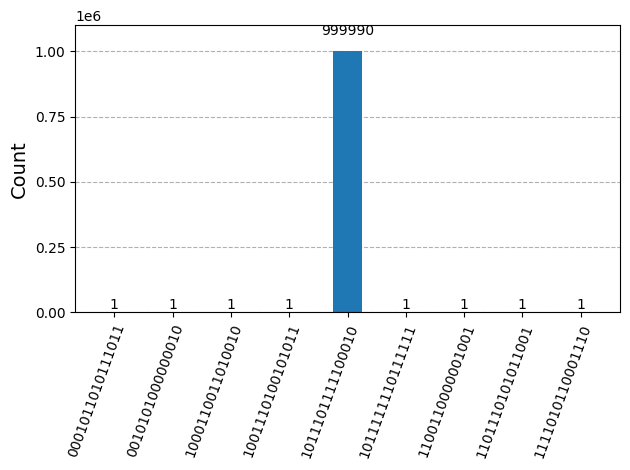

In [45]:
# Alustetaan n-tiloilla
target = format(random.getrandbits(N), f'0{N}b')
print(list(range(1,5)))
print(target)
qc = QuantumCircuit(N)
# Kaikkiin Hadamard:
qc.h(range(N))
init_state = Statevector.from_instruction(qc)
print(init_state)
iterations = int(np.floor((np.pi/4) * np.sqrt(2**N))) # Wikipediasta
oracle_gate = grover_oracle(target, N=N)
diffuser_gate = grover_diffuser(N)
oracle_circuit = QuantumCircuit(N, name="Oracle")
for _ in range(iterations):
    oracle_circuit.append(oracle_gate, list(range(N)))
    oracle_circuit.append(diffuser_gate, list(range(N)))
qc.append(oracle_circuit, list(range(N)))
qc_samples = qc.copy()
qc_samples.measure_all()
grover_result = simulate_measurements(qc_samples, 1000000).get_counts()
top_items = {key: value for key,value in sorted(grover_result.items(), key=lambda x:x[1], reverse=True)[0:9]} # Valitaan kymmenen parasta
# Ensimmäisen jäsenen pitäisi olla haluttu "bitstring":
if target == next(iter(top_items)):
    print(f'Haku onnistui, {target}: {top_items[target]}\nIteraatioita: {iterations}')
plot_histogram(top_items, sort='asc')

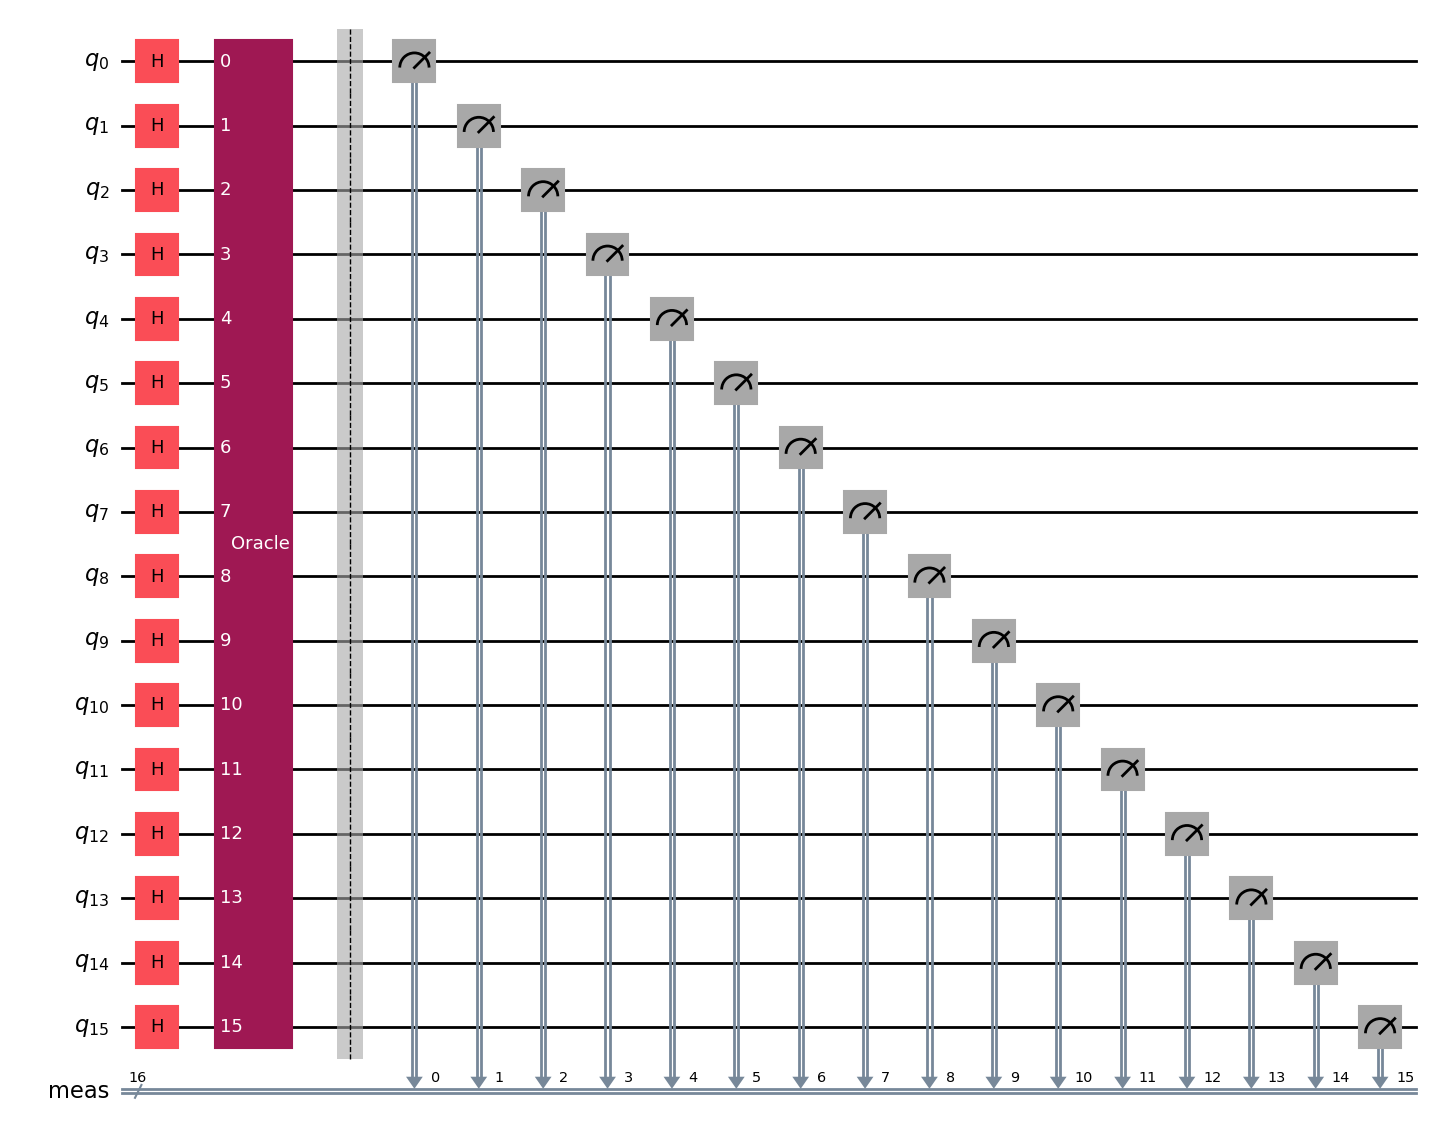

In [48]:
#########
#plot_histogram(grover_result.get_counts())
#result_items = sorted(grover_result.items(), key=lambda x:x[1], reverse=True)
#top_items = result_items[0:9] # valitaan kymmenen yleisintä (sortattu)
# print(result_items)
# for key, val in sorted(grover_result.items(), key=lambda x:x[1], reverse=True):
#     print(f"{int(key, 2)}: {val}")
# Plot only the most frequent outcomes so the chart stays readable.
#plt.bar(top_items.keys(), top_items.values())
#########
qc_samples.draw("mpl")